### Importaciones

In [1]:
import numpy as np
import pandas as pd

### Creacion de dataframe de ausencias

In [2]:
df_ausencias=pd.read_csv("../data/01_raw/ausencias.csv")
df_ausencias.head()

,id_ausencia,id_empleado,fecha_inicio,fecha_fin,tipo_ausencia,justificada,dias
0,1.0,216.0,2022-01-01,2022-01-03 00:00:00.000000000,Permiso,Sí,16.0
1,2.0,240.0,04/01/2022,2022-01-06 03:18:03.094555873,Vacaciones,Sí,3.0
2,3.0,68.0,NaN,2022-01-09 06:36:06.189111747,Permiso,Sí,2.0
3,4.0,NaN,10/01/2022,2022-01-12 09:54:09.283667621,Falta Injustificada,Sí,2.0
4,5.0,142.0,2022-01-13,2022-01-15 13:12:12.378223495,Licencia Médica,Sí,26.0


### Creacion de dataframe de capacitaciones

In [3]:
df_capacitaciones=pd.read_csv("../data/01_raw/capacitaciones.csv")
df_capacitaciones.head()

,id_capacitacion,id_empleado,nombre_curso,fecha_inicio,fecha_fin,horas,estado,nota_final
0,1.0,220.0,Python Avanzado,01/01/2022,2022-02-01,8.0,Abandonado,4.4
1,2.0,66.0,NaN,03/01/2022,2022-02-03,8.0,En curso,1.0
2,3.0,265.0,Gestión de Proyectos,2022-01-06,2022-02-06,80.0,NaN,3.2
3,4.0,134.0,Liderazgo,09/01/2022,2022-02-09,40.0,En curso,1.8
4,5.0,119.0,EXCEL,2022-01-11,11/02/2022,60.0,Completado,5.1


### Creacion de dataframe de empleados

In [4]:
df_empleados=pd.read_csv("../data/01_raw/empleados.csv")
df_empleados.head()

,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada
0,1.0,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,01/01/2015,1147033.0,Indefinido,Completa
1,2.0,Ignacio Núñez Hernández,23306873-1,Logística,Analista,2015-01-12,4563559.0,Plazo Fijo,Completa
2,3.0,José Díaz Muñoz,6281564-5,RRHH,Analista,24/01/2015,876120.0,Indefinido,Completa
3,4.0,Felipe Castro Muñoz,5967608-9,Operaciones,Analista,04/02/2015,4201812.0,Práctica,Completa
4,5.0,Carolina Zambrano Díaz,10140262-2,RRHH,Coordinador,16/02/2015,1183831.0,Plazo Fijo,Completa


### Creacion de dataframe de evaluaciones

In [5]:
df_evaluaciones=pd.read_csv("../data/01_raw/evaluaciones.csv")  
df_evaluaciones.head()

,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez
3,NaN,NaN,NaN,4.2,4.4,1.8,Vicente Gatica Silva
4,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela


### Pipeline para explorar el dataframe

In [6]:

def explorar_dataframe(df, nombre):
    """
    Genera un diagnóstico completo de un DataFrame.
    Muestra forma, tipos, nulos, duplicados y estadísticas.
    """
    print(f"\n{'='*60}")
    print(f"  DIAGNÓSTICO: {nombre}")
    print(f"{'='*60}")
    print(f"\nShape: {df.shape[0]} filas × {df.shape[1]} columnas")
    print(f"\nTipos de datos:")
    print(df.dtypes)
    
    print(f"\nValores nulos por columna:")
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df) * 100).round(2)
    resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje(%)': porcentaje})
    print(resumen_nulos[resumen_nulos['Nulos'] > 0])
    print(f"\n🔁 Filas duplicadas: {df.duplicated().sum()}")
    print(f"\n📊 Estadísticas descriptivas:")
    print(df.describe())
    print(f"\n👀 Primeras 3 filas:")
    print(df.head(3))

# Ejecutar diagnóstico para los 4 DataFrames
explorar_dataframe(df_empleados, "EMPLEADOS")
explorar_dataframe(df_evaluaciones, "EVALUACIONES")
explorar_dataframe(df_capacitaciones, "CAPACITACIONES")
explorar_dataframe(df_ausencias, "AUSENCIAS")


  DIAGNÓSTICO: EMPLEADOS

Shape: 309 filas × 9 columnas

Tipos de datos:
id_empleado      float64
nombre               str
rut                  str
departamento         str
cargo                str
fecha_ingreso        str
salario              str
tipo_contrato        str
jornada              str
dtype: object

Valores nulos por columna:
               Nulos  Porcentaje(%)
id_empleado       15           4.85
nombre            17           5.50
rut               15           4.85
departamento      12           3.88
cargo             14           4.53
fecha_ingreso      9           2.91
salario           13           4.21
tipo_contrato     15           4.85
jornada           22           7.12

🔁 Filas duplicadas: 9

📊 Estadísticas descriptivas:
       id_empleado
count   294.000000
mean    148.530612
std      86.669889
min       1.000000
25%      73.250000
50%     146.500000
75%     222.750000
max     300.000000

👀 Primeras 3 filas:
   id_empleado                   nombre         rut   

### Pipeline 2, Limpia los 4 DataFrames y los guarda


In [7]:
def limpiar_empleados(df):
    """Limpia el DataFrame de empleados."""
    df = df.copy()
    
    # 1. Eliminar duplicados
    df = df.drop_duplicates()
    
    # 2. Eliminar filas donde nombre o rut sean nulos (datos clave)
    df = df.dropna(subset=['nombre', 'rut'])
    
    # 3. Rellenar nulos en columnas categóricas
    df['departamento'] = df['departamento'].fillna('Sin Asignar')
    df['cargo']        = df['cargo'].fillna('Sin Asignar')
    df['tipo_contrato']= df['tipo_contrato'].fillna('Sin Asignar')
    df['jornada']      = df['jornada'].fillna('Sin Asignar')
    
    # 4. Corregir tipos: id_empleado → int, salario → float
    df['id_empleado'] = pd.to_numeric(df['id_empleado'], errors='coerce')
    df['salario']     = pd.to_numeric(df['salario'], errors='coerce')
    df = df.dropna(subset=['id_empleado'])
    df['id_empleado'] = df['id_empleado'].astype(int)
    
    # 5. Estandarizar fechas formato mixto → YYYY-MM-DD
    df['fecha_ingreso'] = pd.to_datetime(df['fecha_ingreso'], dayfirst=True, errors='coerce')
    
    # 6. Normalizar strings (strip + title case)
    df['nombre']       = df['nombre'].str.strip().str.title()
    df['departamento'] = df['departamento'].str.strip().str.title()
    df['cargo']        = df['cargo'].str.strip().str.title()
    
    return df


def limpiar_evaluaciones(df):
    """Limpia el DataFrame de evaluaciones."""
    df = df.copy()
    
    # 1. Eliminar duplicados
    df = df.drop_duplicates()
    
    # 2. Eliminar filas sin id_empleado (clave de relación)
    df = df.dropna(subset=['id_empleado'])
    
    # 3. Rellenar nulos numéricos con la mediana
    for col in ['puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas']:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
    
    # 4. Tratar outliers en puntaje_desempeno con IQR
    Q1 = df['puntaje_desempeno'].quantile(0.25)
    Q3 = df['puntaje_desempeno'].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    df['puntaje_desempeno'] = df['puntaje_desempeno'].clip(limite_inf, limite_sup)
    
    # 5. Corregir tipos
    df['id_empleado']   = pd.to_numeric(df['id_empleado'], errors='coerce').astype(int)
    df['id_evaluacion'] = pd.to_numeric(df['id_evaluacion'], errors='coerce')
    
    # 6. Rellenar nulos en texto
    df['periodo']   = df['periodo'].fillna('Sin Periodo')
    df['evaluador'] = df['evaluador'].fillna('Sin Evaluador')
    
    return df


def limpiar_capacitaciones(df):
    """Limpia el DataFrame de capacitaciones."""
    df = df.copy()
    
    # 1. Eliminar duplicados
    df = df.drop_duplicates()
    
    # 2. Eliminar filas sin id_empleado
    df = df.dropna(subset=['id_empleado'])
    
    # 3. Rellenar nulos en texto
    df['nombre_curso'] = df['nombre_curso'].fillna('Sin Nombre')
    df['estado']       = df['estado'].fillna('Sin Estado')
    
    # 4. Rellenar nulos numéricos con mediana
    df['horas']      = df['horas'].fillna(df['horas'].median())
    df['nota_final'] = df['nota_final'].fillna(df['nota_final'].median())
    
    # 5. Estandarizar fechas formato mixto
    df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], dayfirst=True, errors='coerce')
    df['fecha_fin']    = pd.to_datetime(df['fecha_fin'],    dayfirst=True, errors='coerce')
    
    # 6. Corregir tipos
    df['id_empleado'] = pd.to_numeric(df['id_empleado'], errors='coerce').astype(int)
    
    return df


def limpiar_ausencias(df):
    """Limpia el DataFrame de ausencias."""
    df = df.copy()
    
    # 1. Eliminar duplicados
    df = df.drop_duplicates()
    
    # 2. Eliminar filas sin id_empleado
    df = df.dropna(subset=['id_empleado'])
    
    # 3. Estandarizar fechas (incluyendo timestamps)
    df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], dayfirst=True, errors='coerce')
    df['fecha_fin']    = pd.to_datetime(df['fecha_fin'],    dayfirst=True, errors='coerce')
    
    # 4. Rellenar nulos en texto
    df['tipo_ausencia'] = df['tipo_ausencia'].fillna('Sin Tipo')
    df['justificada']   = df['justificada'].fillna('No')
    
    # 5. Rellenar nulos en dias con mediana
    df['dias'] = df['dias'].fillna(df['dias'].median())
    
    # 6. Corregir tipos
    df['id_empleado'] = pd.to_numeric(df['id_empleado'], errors='coerce').astype(int)
    
    return df


# ── Ejecutar limpieza ──────────────────────────────────────
df_empleados_clean      = limpiar_empleados(df_empleados)
df_evaluaciones_clean   = limpiar_evaluaciones(df_evaluaciones)
df_capacitaciones_clean = limpiar_capacitaciones(df_capacitaciones)
df_ausencias_clean      = limpiar_ausencias(df_ausencias)

# ── Guardar en 02_intermediate ─────────────────────────────
df_empleados_clean.to_csv("../data/02_intermediate/empleados_clean.csv",           index=False)
df_evaluaciones_clean.to_csv("../data/02_intermediate/evaluaciones_clean.csv",     index=False)
df_capacitaciones_clean.to_csv("../data/02_intermediate/capacitaciones_clean.csv", index=False)
df_ausencias_clean.to_csv("../data/02_intermediate/ausencias_clean.csv",           index=False)

print("✅ Pipeline 2 completado. Archivos guardados en 02_intermediate/")

# ── Verificación rápida ────────────────────────────────────
for nombre, df in [("EMPLEADOS", df_empleados_clean), 
                   ("EVALUACIONES", df_evaluaciones_clean),
                   ("CAPACITACIONES", df_capacitaciones_clean), 
                   ("AUSENCIAS", df_ausencias_clean)]:
    print(f"\n{nombre}: {df.shape} | Nulos restantes: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")

✅ Pipeline 2 completado. Archivos guardados en 02_intermediate/

EMPLEADOS: (255, 9) | Nulos restantes: 166 | Duplicados: 0

EVALUACIONES: (476, 7) | Nulos restantes: 17 | Duplicados: 0

CAPACITACIONES: (378, 8) | Nulos restantes: 533 | Duplicados: 0

AUSENCIAS: (335, 7) | Nulos restantes: 515 | Duplicados: 0


### Visualizar lo nulos restantes

In [8]:
# ── Diagnóstico de nulos restantes ────────────────────────
for nombre, df in [("EMPLEADOS", df_empleados_clean), 
                   ("EVALUACIONES", df_evaluaciones_clean),
                   ("CAPACITACIONES", df_capacitaciones_clean), 
                   ("AUSENCIAS", df_ausencias_clean)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"\n{nombre}:")
        print(nulos)


EMPLEADOS:
fecha_ingreso    143
salario           23
dtype: int64

EVALUACIONES:
id_evaluacion    17
dtype: int64

CAPACITACIONES:
id_capacitacion     16
fecha_inicio       209
fecha_fin          308
dtype: int64

AUSENCIAS:
id_ausencia      25
fecha_inicio    279
fecha_fin       211
dtype: int64


### Pipeline 3 es para la transformación

In [9]:
df_master = df_empleados_clean.merge(
    df_evaluaciones_clean, 
    on='id_empleado', 
    how='left'
)
print(f"Forma del dataset integrado: {df_master.shape}")
df_master.head() 

Forma del dataset integrado: (459, 15)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,id_evaluacion,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,217.0,Sin Periodo,4.3,1.7,5.8,Antonia Vergara Rodríguez
1,2,Ignacio Núñez Hernández,23306873-1,Logística,Analista,NaT,4563559.0,Plazo Fijo,Completa,190.0,Sin Periodo,6.3,3.9,1.3,Vicente Pérez Silva
2,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,165.0,2023-S1,1.3,4.6,4.2,Sin Evaluador
3,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,276.0,2023-S2,4.3,5.8,6.8,Daniela Rojas Rivera
4,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,NaN,2022-S2,6.6,3.7,3.4,Amanda Núñez Fuentes


In [10]:
# tener un registro único por empleado con sus promedios
df_resumen_eval = df_evaluaciones_clean.groupby('id_empleado').agg({
    'puntaje_desempeno': 'mean',
    'competencias_tecnicas': 'mean',
    'competencias_blandas': 'mean'
}).reset_index()

# en esta parte se les da un nuevo nombre a las columnas
df_resumen_eval.columns = ['id_empleado', 'avg_desempeno', 'avg_tecnicas', 'avg_blandas']

# Union con empleados
df_primary = df_empleados_clean.merge(df_resumen_eval, on='id_empleado', how='left')
print(f"Dataset consolidado: {df_primary.shape}")
df_primary.head()

#los datos que le pertenecian a "jose diaz muños" ya no se encuentran repetidos
#tambien se puede observar que "felipe Castro Muñoz" tiene valores NaN ya que no tiene evaluaciones egistradas

Dataset consolidado: (255, 12)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,avg_desempeno,avg_tecnicas,avg_blandas
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,4.30,1.700,5.80
1,2,Ignacio Núñez Hernández,23306873-1,Logística,Analista,NaT,4563559.0,Plazo Fijo,Completa,6.30,3.900,1.30
2,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,4.25,4.825,4.35
3,4,Felipe Castro Muñoz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Práctica,Completa,NaN,NaN,NaN
4,5,Carolina Zambrano Díaz,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,6.00,1.700,3.10


### Sumar total de días de ausencia por empleado

In [11]:
df_resumen_ausencias = df_ausencias_clean.groupby('id_empleado').agg({
    'dias': 'sum'
}).rename(columns={'dias': 'total_dias_ausencia'}).reset_index()

# Sumar total de horas de capacitación
df_resumen_capacitaciones = df_capacitaciones_clean.groupby('id_empleado').agg({
    'horas': 'sum'
}).rename(columns={'horas': 'total_horas_capacitacion'}).reset_index()

# Unión al dataset
df_primary = df_primary.merge(df_resumen_ausencias, on='id_empleado', how='left')
df_primary = df_primary.merge(df_resumen_capacitaciones, on='id_empleado', how='left')

# Remplazar con 0 a quienes no tengan ausencias o capacitaciones
df_primary['total_dias_ausencia'] = df_primary['total_dias_ausencia'].fillna(0)
df_primary['total_horas_capacitacion'] = df_primary['total_horas_capacitacion'].fillna(0)

print(f"Dataset Final Integrado: {df_primary.shape}")
df_primary.head()

Dataset Final Integrado: (255, 14)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,avg_desempeno,avg_tecnicas,avg_blandas,total_dias_ausencia,total_horas_capacitacion
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,4.30,1.700,5.80,17.0,40.0
1,2,Ignacio Núñez Hernández,23306873-1,Logística,Analista,NaT,4563559.0,Plazo Fijo,Completa,6.30,3.900,1.30,29.0,64.0
2,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,4.25,4.825,4.35,38.0,0.0
3,4,Felipe Castro Muñoz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Práctica,Completa,NaN,NaN,NaN,35.0,16.0
4,5,Carolina Zambrano Díaz,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,6.00,1.700,3.10,27.0,0.0


### Guardar el CSV

In [12]:
df_primary.to_csv("../data/03_primary/dataset_final_integrado.csv", index=False)

### Validacion de la creacion del csv

In [13]:
import os

# en este caso se verifica si el archivo "dataset_final_integrado" se creó y por eso se importa os
if os.path.exists("../data/03_primary/dataset_final_integrado.csv"):
    df_verificar = pd.read_csv("../data/03_primary/dataset_final_integrado.csv")
    print("Archivo encontrado")
    print(f"Dimensiones finales: {df_verificar.shape}")
    print(f"Columnas guardadas: {list(df_verificar.columns)}")
else:
    print("archivo no encontrado.")

Archivo encontrado
Dimensiones finales: (255, 14)
Columnas guardadas: ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo', 'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada', 'avg_desempeno', 'avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion']


### Validacion de datos

In [14]:
# Comparación antes/después para el Informe Técnico
print("--- VALIDACIÓN DE INTEGRIDAD ---")
print(f"Total empleados originales: {len(df_empleados_clean)}")
print(f"Total empleados en dataset final: {len(df_verificar)}")

# Verificacion si hubo pérdida de datos
if len(df_empleados_clean) == len(df_verificar):
    print("Validación exitosa")
else:
    print("El número de registros ha cambiado")

# Verificacion de existencia de nulos en columnas
nulos_finales = df_verificar[['id_empleado', 'nombre', 'rut']].isnull().sum().sum()
print(f"Nulos en columnas clave: {nulos_finales}")  #al salir 0 quiere decir que no hubo perdida de datos

--- VALIDACIÓN DE INTEGRIDAD ---
Total empleados originales: 255
Total empleados en dataset final: 255
Validación exitosa
Nulos en columnas clave: 0


In [15]:
params = {
    'cleaning': {
        'outlier_threshold': 1.5,
        'default_category': "Sin Asignar"
    },
    'transform': {
        'primary_key': "id_empleado",
        'evaluation_metrics': ["puntaje_desempeno", "competencias_tecnicas", "competencias_blandas"]
    }
}

# Ejemplo de cómo se usaría en tu función de evaluaciones
def limpiar_evaluaciones_pro(df, parameters):
    df = df.copy()
    threshold = parameters['cleaning']['outlier_threshold']
    
    # Tratar outliers usando el parámetro
    Q1 = df['puntaje_desempeno'].quantile(0.25)
    Q3 = df['puntaje_desempeno'].quantile(0.75)
    IQR = Q3 - Q1
    df['puntaje_desempeno'] = df['puntaje_desempeno'].clip(Q1 - threshold * IQR, Q3 + threshold * IQR)
    return df

print("Funciones adaptadas para usar parámetros externos.")

Funciones adaptadas para usar parámetros externos.


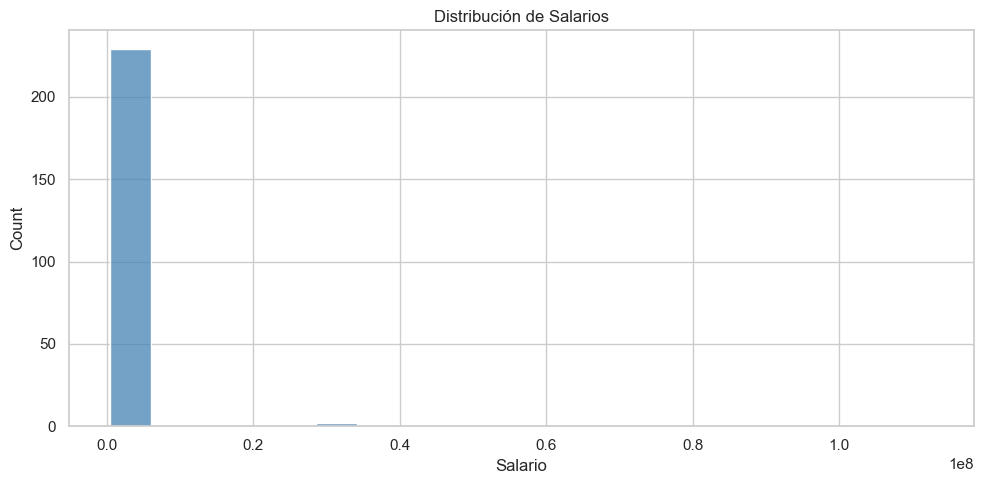

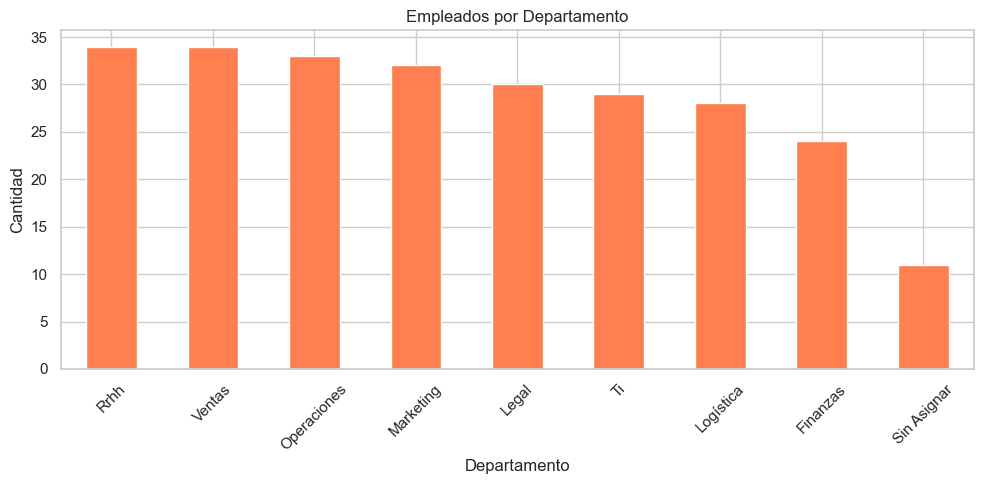

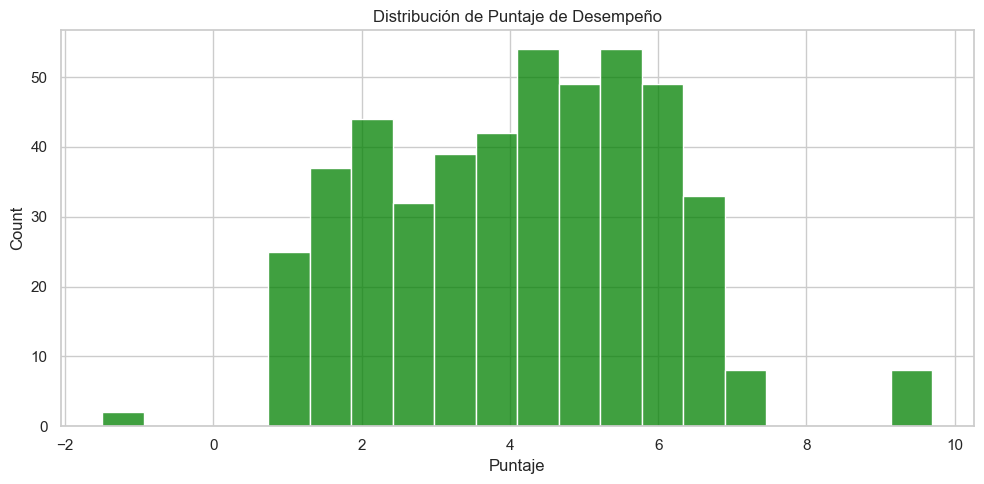

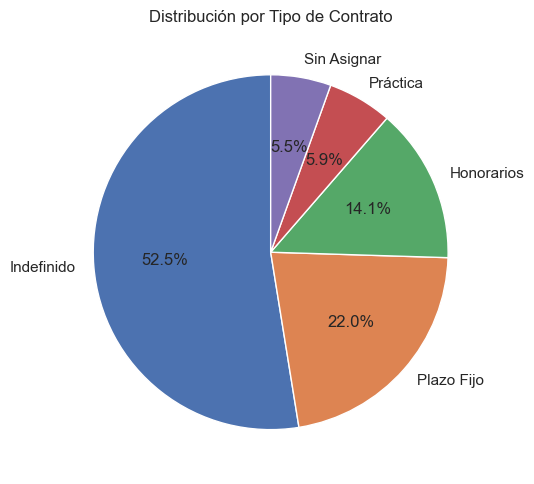

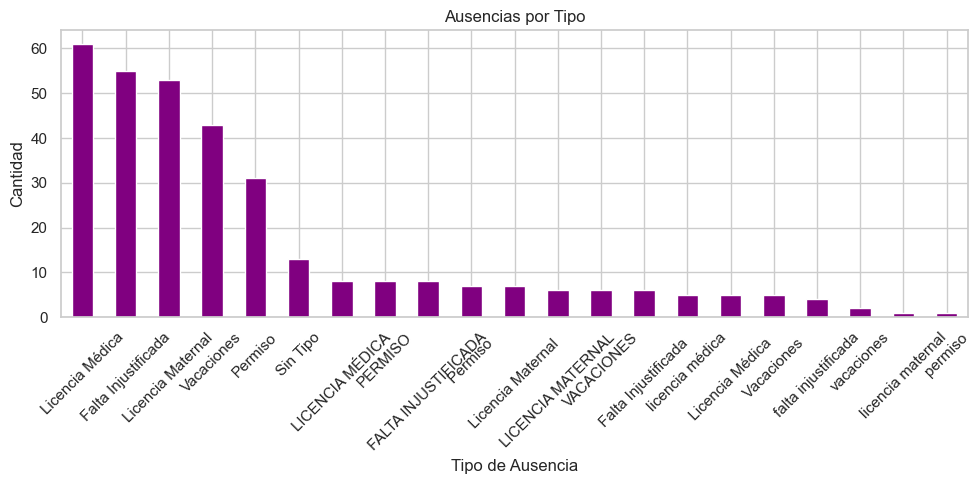

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

# 1. Distribución de salarios
plt.figure()
sns.histplot(df_empleados_clean["salario"].dropna(), bins=20, color="steelblue")
plt.title("Distribución de Salarios")
plt.xlabel("Salario")
plt.tight_layout()
plt.show()

# 2. Empleados por departamento
plt.figure()
df_empleados_clean["departamento"].value_counts().plot(kind="bar", color="coral")
plt.title("Empleados por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Distribución de puntaje de desempeño
plt.figure()
sns.histplot(df_evaluaciones_clean["puntaje_desempeno"], bins=20, color="green")
plt.title("Distribución de Puntaje de Desempeño")
plt.xlabel("Puntaje")
plt.tight_layout()
plt.show()

# 4. Tipo de contrato
plt.figure()
df_empleados_clean["tipo_contrato"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90
)
plt.title("Distribución por Tipo de Contrato")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5. Ausencias por tipo
plt.figure()
df_ausencias_clean["tipo_ausencia"].value_counts().plot(kind="bar", color="purple")
plt.title("Ausencias por Tipo")
plt.xlabel("Tipo de Ausencia")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()